In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import csv data as pandas dataframe

In [28]:
df = pd.read_csv("../data/crop_yield.csv")

### Show top 5 records

In [29]:
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [30]:
df.shape

(19689, 10)

### Check data types

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  str    
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  str    
 3   State            19689 non-null  str    
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), str(3)
memory usage: 2.1 MB


### Check statistics of dataset

In [32]:
df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


### Checking if yield really is production/area 

In [33]:
df["calculated_yield"] = df["Production"]/df["Area"]
print(df[["Yield", "calculated_yield"]].head(10))

         Yield  calculated_yield
0     0.796087          0.768255
1     0.710435          0.705891
2     0.238333          0.027638
3  5238.051739       6456.298331
4     0.420909          0.456584
5     0.643636          0.667771
6     0.465455          0.505874
7     9.919565          9.565118
8     0.461364          0.510794
9     0.615652          0.766080


In [8]:
print("Difference stats:\n", (df["Yield"] - df["calculated_yield"]).describe())

Difference stats:
 count    19689.000000
mean        -3.886774
std         87.755023
min      -2981.430106
25%         -0.081360
50%         -0.003636
75%          0.033796
max       3733.993254
dtype: float64


In [34]:
df["abs_diff"] = (df["Yield"] - df["calculated_yield"]).abs()
crop_diff = df.groupby("Crop")["abs_diff"].mean().sort_values(ascending = False)
print(crop_diff.head(15))

Crop
Coconut           629.983553
Sugarcane           4.517655
Banana              2.851476
Cashewnut           2.629878
Onion               2.315515
Tapioca             1.500108
Potato              0.877278
Jute                0.638134
Oilseeds total      0.596904
Sweet potato        0.549019
Garlic              0.509369
Ginger              0.462146
other oilseeds      0.437283
Mesta               0.367727
Tobacco             0.349160
Name: abs_diff, dtype: float64


- From the above observations we can say that yield is really Production/Area for the vast majority of rows in this dataset.
- Coconut is a massive outlier — 630, wildly higher than everything else. It is most probably a unit-inconsistency problem, not a leakage problem.

Yield = Production/Area is true so we cannot give production and area as inputs to the model as you're basically handing it the answer, the model can just do the division instead of actually learning anything about farming 

### Check duplicate values

In [35]:
df.duplicated().sum()

np.int64(0)

There are no duplicate values in the dataset

### Checking the number of unique values of each column

In [36]:
df.nunique()

Crop                   55
Crop_Year              24
Season                  6
State                  30
Area                13644
Production          14016
Annual_Rainfall       634
Fertilizer          18598
Pesticide           17405
Yield               13551
calculated_yield    17951
abs_diff            18451
dtype: int64

In [12]:
#define numerical and categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != "str"]
categorical_features = [feature for feature in df.columns if df[feature].dtype == "str"]

#print columns
print(f"We have {len(numeric_features)} numerical features: {numeric_features}")
print(f"We have {len(categorical_features)} categorical features: {categorical_features}")

We have 9 numerical features: ['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield', 'calculated_yield', 'abs_diff']
We have 3 categorical features: ['Crop', 'Season', 'State']


In [13]:
for col in categorical_features:
    print(df[col].value_counts(),"\n")

Crop
Rice                     1197
Maize                     975
Moong(Green Gram)         740
Urad                      733
Groundnut                 725
Sesamum                   685
Potato                    628
Sugarcane                 605
Wheat                     545
Rapeseed &Mustard         528
Bajra                     524
Jowar                     513
Arhar/Tur                 508
Ragi                      498
Gram                      490
Small millets             485
Cotton(lint)              476
Onion                     454
Sunflower                 441
Dry chillies              419
Other Kharif pulses       382
Horse-gram                371
Peas & beans (Pulses)     369
Tobacco                   364
Other  Rabi pulses        355
Soyabean                  349
Turmeric                  337
Masoor                    324
Ginger                    323
Linseed                   308
Castor seed               300
Barley                    297
Sweet potato              273
Garli

In [37]:
print(df["Season"].apply(lambda x: repr(x)).unique()) #repr(x) shows values with quotes visible, so we can see hidden whitespace
print(df["Crop"].str.strip().nunique(), "vs original:", df["Crop"].nunique())

<ArrowStringArray>
[''Whole Year '', ''Kharif     '', ''Rabi       '', ''Autumn     '',
 ''Summer     '', ''Winter     '']
Length: 6, dtype: str
55 vs original: 55


In [38]:
df["Season"] = df["Season"].str.strip()
print(df["Season"].unique())

<ArrowStringArray>
['Whole Year', 'Kharif', 'Rabi', 'Autumn', 'Summer', 'Winter']
Length: 6, dtype: str


In [39]:
df["Crop"] = df["Crop"].str.strip()
df["State"] = df["State"].str.strip()

## Exploring Data (Visualization)

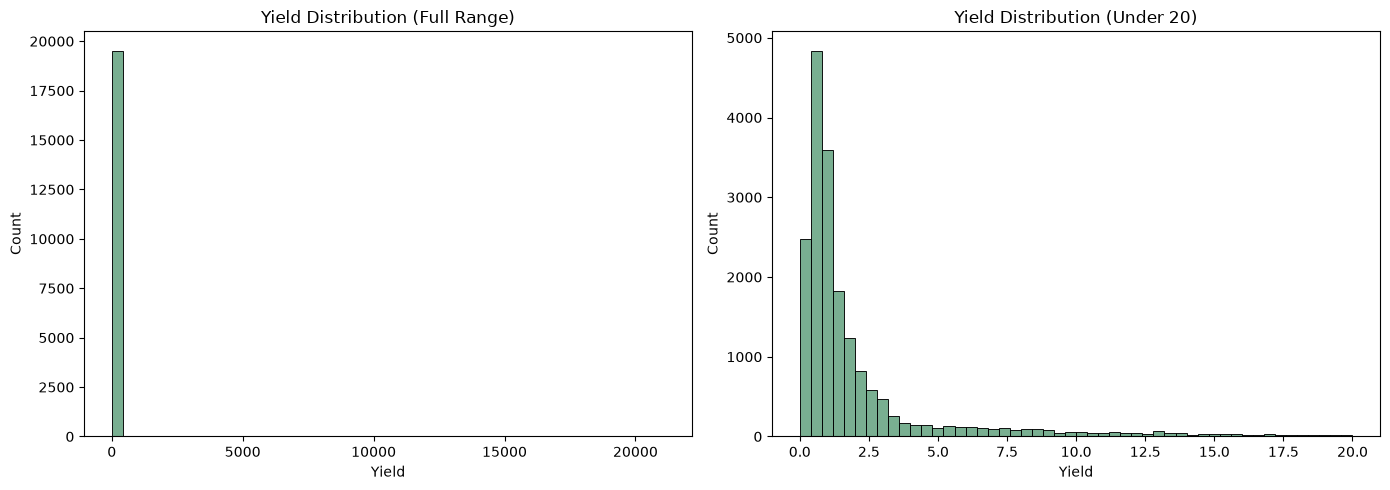

In [40]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
sns.histplot(df["Yield"], bins = 50, color = "#4C956C", ax = axes[0])
axes[0].set_title("Yield Distribution (Full Range)")
axes[0].set_xlabel("Yield")

sns.histplot(df[df["Yield"] < 20]["Yield"], bins =50, color = "#4C956C", ax = axes[1])
axes[1].set_title("Yield Distribution (Under 20)")
axes[1].set_xlabel("Yield")

plt.tight_layout()
plt.show()

In [41]:
top_yields = df.groupby("Crop")["Yield"].max().sort_values(ascending = False)
print(top_yields.head(10))

Crop
Coconut         21105.000000
Maize             989.870000
Onion             381.420000
Cashewnut         338.548966
Potato            311.020000
Sugarcane         165.000000
Banana            126.387692
Cotton(lint)       95.993913
Bajra              74.303077
Sesamum            69.366667
Name: Yield, dtype: float64


- Most crops have low yield values (under 3), but a few numbers are extremely high — this makes the data "skewed," meaning it's not evenly spread out.
- Coconut is the problem crop — its yield values are about 21x higher than anything else in the dataset. This is very likely because coconuts are counted as individual nuts, while other crops are measured by weight — so the numbers aren't actually comparable.
##### Decision: we removed Coconut from the dataset because keeping it in would confuse the model about what a "normal" yield looks like.

In [ ]:
df = df[df["Crop"] != "Coconut"].reset_index(drop = True) #Keep every row except the ones where the crop is Coconut, then renumber the rows so there are no gaps

In [44]:
print("New shape: ", df.shape)

New shape:  (19517, 12)


In [45]:
print("Coconut" in df["Crop"].unique())

False


In [46]:
df = df.drop(columns = ["calculated_yield", "abs_diff"])
print(df.shape)
print(df.columns.tolist())

(19517, 10)
['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']
